<a href="https://colab.research.google.com/github/HanamDavid/-visual_computing_bachue/blob/main/Practica4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Practica 4
En esta practica vamos a empezar a utilizar Herramientas de Inteligencia artificial para procesar datos visuales usando YOLO y SAM
## Subir archivo

In [1]:
from google.colab import files

uploaded = files.upload()
image_filename = list(uploaded.keys())[0]
print(f"Uploaded image: {image_filename}")

Saving S275-legacy-icons__03390.jpg to S275-legacy-icons__03390.jpg
Uploaded image: S275-legacy-icons__03390.jpg


### Inicialización del Modelo


Cargamos el modelo y le pasamos nuestra imagen



In [7]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")
detection_results = model(image_filename)
bboxes = detection_results[0].boxes.xyxy

# Print the bounding boxes to verify
print("Detected Bounding Boxes (xyxy format):")
print(bboxes)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


100%|██████████| 6.25M/6.25M [00:00<00:00, 75.9MB/s]



image 1/1 /content/S275-legacy-icons__03390.jpg: 640x640 1 clock, 518.9ms
Speed: 21.3ms preprocess, 518.9ms inference, 34.4ms postprocess per image at shape (1, 3, 640, 640)
Detected Bounding Boxes (xyxy format):
tensor([[554.9702, 309.9635, 729.3989, 482.0506]])


## Filtrar por clases


In [8]:
import pandas as pd
import torch # Asumiendo que detection_results[0].boxes.cls es un tensor de PyTorch


detected_class_ids = detection_results[0].boxes.cls

# Define los nombres de las clases deseadas
desired_classes = ['sheep', 'zebra']

# Obtén los IDs de clase para las clases deseadas
class_names_dict = model.names
desired_class_ids = [k for k, v in class_names_dict.items() if v in desired_classes]

# --- Nueva lógica para generar la tabla y el "checklist" ---

# Convertir los tensores a listas/arrays de Python para facilitar la manipulación
# Asegúrate de que sean CPU y no estén en formato tensor si vas a hacer operaciones directas con Python
detected_class_ids_list = detected_class_ids.cpu().numpy().tolist()
detected_confidences_list = detection_results[0].boxes.conf.cpu().numpy().tolist()
detected_bboxes_list = detection_results[0].boxes.xyxy.cpu().numpy().tolist()

# Preparar los datos para la tabla
data = []
for i, class_id in enumerate(detected_class_ids_list):
    class_name = class_names_dict.get(int(class_id), 'unknown') # Convierte a int si es necesario
    confidence = detected_confidences_list[i]
    bbox = detected_bboxes_list[i]

    # Verifica si la clase está en las deseadas
    is_desired = '✅ Yes' if class_id in desired_class_ids else '❌ No'

    data.append({
        'ID de Detección': i,
        'Clase ID': int(class_id), # Asegurarse de que sea un int
        'Nombre de Clase': class_name,
        'Confianza': f"{confidence:.2f}", # Formatear a 2 decimales
        'Bounding Box (xyxy)': [round(coord, 2) for coord in bbox], # Redondear coords
        '¿Es Clase Deseada?': is_desired
    })

# Crear el DataFrame de pandas
df = pd.DataFrame(data)

# Mostrar la tabla
print("--- Todas las Detecciones con Checklist ---")
from IPython.display import display # Para una mejor visualización en notebooks
display(df)

# --- La parte original de filtrado sigue siendo útil si quieres los resultados filtrados por separado ---
# (Este bloque no tiene cambios, es solo para referencia si lo quieres mantener)

# Filtrar resultados basados en IDs de clase deseados
filtered_indices = [i for i, class_id in enumerate(detected_class_ids_list) if class_id in desired_class_ids]

# Filtrar bounding boxes y confidence scores
filtered_bboxes = [detected_bboxes_list[i] for i in filtered_indices]
filtered_confidences = [detected_confidences_list[i] for i in filtered_indices]
filtered_class_ids_output = [detected_class_ids_list[i] for i in filtered_indices] # Usar la lista no el tensor

# Almacenar los resultados filtrados
filtered_detection_results = {
    'bboxes': filtered_bboxes,
    'confidences': filtered_confidences,
    'class_ids': filtered_class_ids_output
}

print("\n--- Resultados Filtrados (Solo Clases Deseadas) ---")
print(filtered_detection_results)

--- Todas las Detecciones con Checklist ---


,ID de Detección,Clase ID,Nombre de Clase,Confianza,Bounding Box (xyxy),¿Es Clase Deseada?
0,0,74,clock,0.44,"[554.97, 309.96, 729.4, 482.05]",❌ No



--- Resultados Filtrados (Solo Clases Deseadas) ---
{'bboxes': [], 'confidences': [], 'class_ids': []}


## Resultados


**Reasoning**:
Import necessary libraries and load the image. Check if there are filtered detection results and iterate through them to draw bounding boxes and labels on the image. If not, display the original image with a message.



No objects of the desired classes were detected.


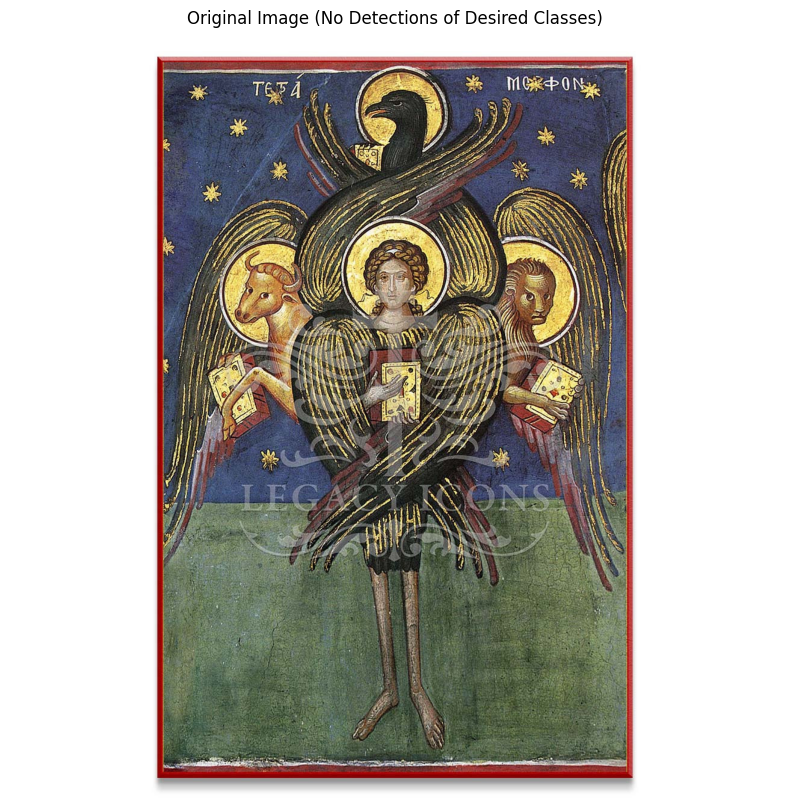

In [9]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Load the original image
try:
    # Read the image file from the uploaded dictionary
    image_array = np.frombuffer(uploaded[image_filename], np.uint8)
    image = cv2.imdecode(image_array, cv2.IMREAD_COLOR)

    if image is None:
        print(f"Error: Could not decode image {image_filename}")
except Exception as e:
    print(f"Error loading image {image_filename}: {e}")
    image = None

# Check if image was loaded successfully and if there are filtered detection results
if image is not None:
    # Check if the list of bounding boxes is not empty
    if filtered_detection_results and filtered_detection_results['bboxes']:
        # Draw bounding boxes and labels
        for bbox, confidence, class_id in zip(
            filtered_detection_results['bboxes'],
            filtered_detection_results['confidences'],
            filtered_detection_results['class_ids']
        ):
            x1, y1, x2, y2 = map(int, bbox)
            class_name = class_names_dict[int(class_id)]
            label = f"{class_name}: {confidence:.2f}"

            # Draw rectangle
            color = (0, 255, 0)  # Green color
            cv2.rectangle(image, (x1, y1), (x2, y2), color, 2)

            # Put label
            cv2.putText(image, label, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

        # Display the image with detections (convert BGR to RGB for matplotlib)
        plt.figure(figsize=(10, 10))
        plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        plt.title("Object Detections")
        plt.axis('off')
        plt.show()
    else:
        # No filtered detection results
        print("No objects of the desired classes were detected.")
        # Display the original image (convert BGR to RGB for matplotlib)
        plt.figure(figsize=(10, 10))
        plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        plt.title("Original Image (No Detections of Desired Classes)")
        plt.axis('off')
        plt.show()
else:
    print("Image could not be loaded.")

**Reasoning**:
Check if there are filtered detection results and save them to a CSV if they exist, otherwise print a message.



In [12]:
import pandas as pd

if filtered_detection_results['bboxes'].shape[0] > 0:
    # Create a DataFrame from the filtered results
    df_detections = pd.DataFrame({
        'x_min': filtered_detection_results['bboxes'][:, 0].tolist(),
        'y_min': filtered_detection_results['bboxes'][:, 1].tolist(),
        'x_max': filtered_detection_results['bboxes'][:, 2].tolist(),
        'y_max': filtered_detection_results['bboxes'][:, 3].tolist(),
        'confidence': filtered_detection_results['confidences'].tolist(),
        'class_id': filtered_detection_results['class_ids'].tolist()
    })

    # Save the DataFrame to a CSV file
    df_detections.to_csv('filtered_detections.csv', index=False)
    print("Filtered detection results saved to 'filtered_detections.csv'")
else:
    print("No filtered detection results to save.")


AttributeError: 'list' object has no attribute 'shape'

In [6]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 58.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 32.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 33.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 84.2 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling 